<a href="https://colab.research.google.com/github/Aminesalem/customer-churn-prediction/blob/main/Customer_Churn_Data_Prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Fix the broken TotalCharges column and drop the 11 missing rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 3. Translate the Target (Churn) to numbers (1 and 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Drop useless ID column and translate all other text to numbers
df.drop('customerID', axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)

# 5. Confirm it worked
print("Data cleaning complete! New shape:", df.shape)

Data cleaning complete! New shape: (7032, 31)


In [4]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# drop target var
X = df.drop('Churn', axis=1)
y = df['Churn']

# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# init and train xgboost
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# get preds and print metrics
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nReport:\n", classification_report(y_test, predictions))

Accuracy: 0.7739872068230277

Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [5]:
# trying to fix that bad recall for class 1
# used scale_pos_weight to help with the imbalance
model_tuned = XGBClassifier(scale_pos_weight=3, random_state=42)
model_tuned.fit(X_train, y_train)

# lower the threshold to catch more churners (recall > accuracy)
probs = model_tuned.predict_proba(X_test)[:, 1]
custom_preds = (probs >= 0.3).astype(int)

print("Tuned Recall Report:\n", classification_report(y_test, custom_preds))

Tuned Recall Report:
               precision    recall  f1-score   support

           0       0.90      0.66      0.76      1033
           1       0.46      0.79      0.58       374

    accuracy                           0.69      1407
   macro avg       0.68      0.73      0.67      1407
weighted avg       0.78      0.69      0.71      1407



In [ ]:
import matplotlib.pyplot as plt

# check what features actually matter for the model
feat_importances = pd.Series(model_tuned.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Factors Driving Churn')
plt.show()

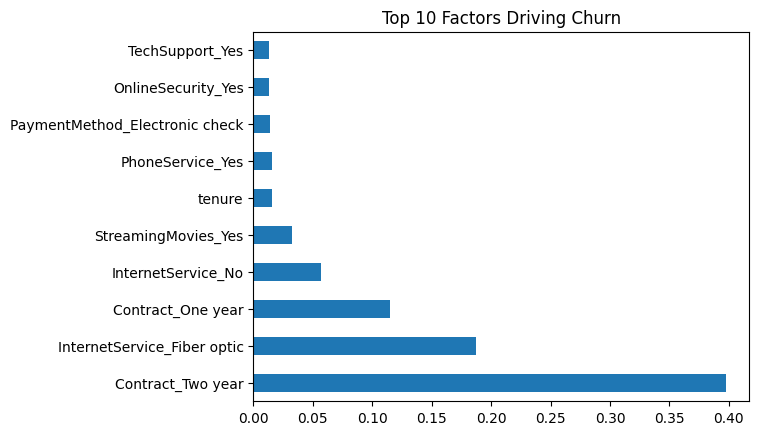

In [6]:
import matplotlib.pyplot as plt

# check what features actually matter for the model
feat_importances = pd.Series(model_tuned.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Factors Driving Churn')
plt.show()